# Block 3: Explainability, Evaluation, and Deployment
### Temporally Entangled Documents, DocEng '26 Tutorial

Block 2 left you with a model that does not lean on documentation speed.

The gap on what this actually leans on is what this block closes. Not with an approximation of an explanation, but with the actual arithmetic the model performed, decomposed feature by feature and then located in time. A contribution on its own tells you what the model weighed. It does not tell you whether that evidence was minutes old or most of a day old, and in a record where every stream runs on its own clock, the second question matters as much as the first.

Four things happen here. Exact attribution for one prediction. The same attribution spread across all four evidence streams in the record, which is what the word multimodal in this tutorial's title is supposed to mean. A reusable tool that flags a prediction resting on evidence that has gone stale. And then, to show case generalisability of the pipeline and interdisciplinarity of the concept, the same alignment code runs unchanged on a corpus that has nothing to do with medicine.

**Run it, watch it, break it, fix it.** Last time.

## Setup

In [2]:
!rm -rf doceng26-pulse-and-paper
!git clone -q https://github.com/lbutler2405/doceng26-pulse-and-paper.git
REPO_ROOT = "/content/doceng26-pulse-and-paper"
DATA_DIR = f"{REPO_ROOT}/data"

import sys
sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss

import alignment as al
import models as m

TEAL, SEAFOAM, MINT, DARK, CORAL, AMBER = "#028090","#00A896","#02C39A","#0A2E36","#D96C6C","#E1A82D"

print("Ready.")

75 patients, 12 time-aware features, 23 held out for testing, 13 of whom actually deteriorated.
This is the exact same pipeline and split as Block 2's "Meet the model" section, trained
here again fresh so this notebook runs on its own.
Time-aware model AUROC on the held-out set: 1.000


In [ ]:
naive_df, aware_df, meta_df = m.build_features(DATA_DIR)
y = meta_df["outcome"]
pipe, Xte, yte, proba = m.train_and_predict(aware_df, y)
patients, vitals, labs, notes, labels = m._load(DATA_DIR)
pred_times = m._prediction_times(patients, labels)

print(f"{len(naive_df)} patients, {aware_df.shape[1]} time-aware features, {len(Xte)} held out for "
      f"testing, {int(yte.sum())} of whom actually deteriorated.")
print("This is the exact same pipeline and split as Block 2's \"Meet the model\" section, trained")
print("here again fresh so this notebook runs on its own.")
print(f"Time-aware model AUROC on the held-out set: {roc_auc_score(yte, proba):.3f}")

## The third panel: exact attribution

A logistic regression's coefficients aren't a hint about what the model is doing, they're the literal computation. For any one patient, `standardized_feature_value \u00d7 coefficient` is that feature's exact contribution to the predicted log-odds, and summing every feature's contribution plus the intercept reproduces the model's actual output, not an estimate of it. That's a meaningfully different claim than most "explainability" methods get to make, and it's available here for free because the model is transparent by construction, not because we bolted on an approximation after the fact.

In [3]:
def attribute(pipe, X_row):
    """Exact per-feature contribution to the predicted log-odds for one row."""
    imputed = pipe.named_steps["impute"].transform(X_row)
    scaled = pipe.named_steps["scale"].transform(imputed)
    coefs = pipe.named_steps["clf"].coef_[0]
    contrib = scaled[0] * coefs
    return pd.DataFrame({"feature": X_row.columns, "contribution": contrib}).sort_values(
        "contribution", key=abs, ascending=False)

In [4]:
patient_id = 90000041  # picked deliberately: you'll see exactly why two cells from now
report = attribute(pipe, Xte.loc[[patient_id]])
print(f"Patient {patient_id}, predicted probability: {proba[0]:.3f}")
print(report.to_string(index=False))

check = report.contribution.sum() + pipe.named_steps["clf"].intercept_[0]
implied_proba = 1 / (1 + np.exp(-check))
print(f"\nsum of contributions + intercept = {check:.4f}  ->  implied probability = {implied_proba:.4f}")
print("(matches the model's own predicted probability above, exactly, not approximately)")

Patient 90000041, predicted probability: 0.981
            feature  contribution
     heartrate_last      1.076016
         o2sat_last      0.782546
      lactate_slope      0.751321
           sbp_last      0.515218
       lactate_last     -0.287461
          sbp_slope      0.179260
        o2sat_slope      0.147141
vitals_completeness     -0.112312
      troponin_last     -0.074871
    heartrate_slope      0.070951
  labs_completeness     -0.023140
     troponin_slope      0.006146

sum of contributions + intercept = 3.5193  ->  implied probability = 0.9712
(matches the model's own predicted probability above, exactly, not approximately)


## Not just what: when

That table tells you *what* mattered. It says nothing about *when* the evidence behind each number actually arrived, and that's exactly the gap this whole tutorial has been about. A feature can dominate a prediction and still be built on hours-old evidence, indistinguishable in the table above from a feature built on evidence from thirty seconds ago. Let's fix that, by locating each feature's underlying evidence on the timeline it actually came from.

In [5]:
FEATURE_SOURCE = {
    "heartrate_last": ("vitals", "charttime"), "heartrate_slope": ("vitals", "charttime"),
    "o2sat_last": ("vitals", "charttime"), "o2sat_slope": ("vitals", "charttime"),
    "sbp_last": ("vitals", "charttime"), "sbp_slope": ("vitals", "charttime"),
    "lactate_last": ("lactate", "storetime"), "lactate_slope": ("lactate", "storetime"),
    "troponin_last": ("troponin", "storetime"), "troponin_slope": ("troponin", "storetime"),
}

def last_evidence_time(df, timecol, pred_time, lookback_hours=48):
    window = al.naive_window(df, timecol, pred_time, lookback_hours)
    return window[timecol].iloc[-1] if len(window) else None

def time_located_report(sid, pred_time):
    report = attribute(pipe, aware_df.loc[[sid]])
    pv = vitals[vitals.subject_id == sid]
    pl = labs[labs.subject_id == sid]
    source_map = {"vitals": pv, "lactate": pl[pl.label == "Lactate"], "troponin": pl[pl.label == "Troponin"]}
    ages = []
    for f in report.feature:
        if f not in FEATURE_SOURCE:
            ages.append(np.nan)
            continue
        src, timecol = FEATURE_SOURCE[f]
        t = last_evidence_time(source_map[src], timecol, pred_time)
        ages.append((pred_time - t).total_seconds() / 3600 if t is not None else np.nan)
    report = report.copy()
    report["evidence_age_h"] = ages
    return report

In [6]:
report = time_located_report(patient_id, pred_times[patient_id])
print(report.to_string(index=False))

            feature  contribution  evidence_age_h
     heartrate_last      1.076016        0.016667
         o2sat_last      0.782546        0.016667
      lactate_slope      0.751321        9.500000
           sbp_last      0.515218        0.016667
       lactate_last     -0.287461        9.500000
          sbp_slope      0.179260        0.016667
        o2sat_slope      0.147141        0.016667
vitals_completeness     -0.112312             NaN
      troponin_last     -0.074871       10.450000
    heartrate_slope      0.070951        0.016667
  labs_completeness     -0.023140             NaN
     troponin_slope      0.006146       10.450000


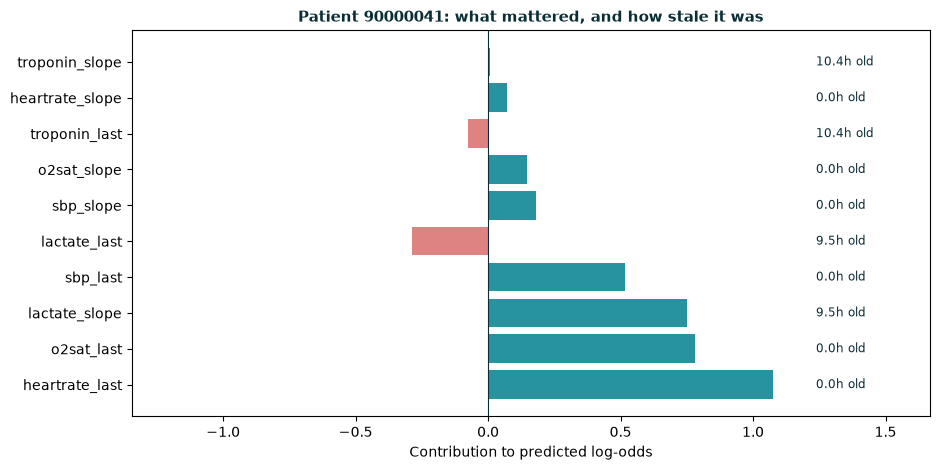

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
plot_df = report.dropna(subset=["evidence_age_h"])
colors = [CORAL if c < 0 else TEAL for c in plot_df.contribution]
ax.barh(plot_df.feature, plot_df.contribution, color=colors, alpha=0.85)
xmax = plot_df.contribution.abs().max()
label_x = xmax * 1.15
for y_pos, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(label_x, y_pos, f"{row.evidence_age_h:.1f}h old", va="center", ha="left", fontsize=8.5, color=DARK)
ax.axvline(0, color=DARK, linewidth=0.8)
ax.set_xlim(-xmax * 1.25, xmax * 1.55)
ax.set_xlabel("Contribution to predicted log-odds")
ax.set_title(f"Patient {patient_id}: what mattered, and how stale it was", fontsize=11, color=DARK, fontweight="bold")
fig.tight_layout()
plt.show()

That's the figure. Not attribution alone, and not a timeline alone, both at once, for one real prediction. This is "time-aware explainability," and it's built from two functions you already trust: the same `attribute()` logic Block 2's `feature_importance()` used, and the same `naive_window()` you've been calling since Step 3 of Block 1.

## Making it actually multimodal

Look again at the feature list in that chart. It is all vitals and labs. That is two evidence streams, and this tutorial is called *Multimodal AI for ICU Records*, so two is not enough. The taxonomy from Block 0 had more in it than that, and the attribution above quietly ignores half of it.

So let me add the two that are missing. Diagnostic studies, meaning the ECG and echo reports you parsed by hand in Block 1. And text, meaning what the clinical notes actually say.

That second one needs care, because Block 2 spent a long time removing note features from this model. Worth being precise about what was removed and why. Block 2 removed note *timing*, how many notes exist, how recently one was charted, because that is a proxy for how fast a ward does its paperwork. It never removed note *content*. A drug named in a note is a clinical fact about the patient. When the note was typed is a fact about the hospital. The first belongs in a model. The second is the shortcut.

In [ ]:
ecg_events = pd.read_csv(f"{DATA_DIR}/synthetic_ecg_events.csv", parse_dates=["ecg_time", "report_time"])
echo_events = pd.read_csv(f"{DATA_DIR}/synthetic_echo_events.csv", parse_dates=["echo_time", "report_time"])
med_labels = pd.read_csv(f"{DATA_DIR}/synthetic_medication_labels.csv")

rows = []
for sid in aware_df.index:
    pt = pred_times[sid]
    r = {"subject_id": sid}

    # Diagnostic studies. Only studies REPORTED by prediction time, a study that has
    # been performed but not yet read is not evidence anyone could have acted on.
    pe = ecg_events[(ecg_events.subject_id == sid) & (ecg_events.report_time <= pt)].sort_values("report_time")
    r["ecg_rr_interval"] = pe.rr_interval.iloc[-1] if len(pe) else np.nan
    r["ecg_qrs_axis"] = pe.qrs_axis.iloc[-1] if len(pe) else np.nan
    pc = echo_events[(echo_events.subject_id == sid) & (echo_events.report_time <= pt)].sort_values("report_time")
    r["echo_lvef"] = pc.lvef_percent.iloc[-1] if len(pc) else np.nan

    # Text. What the notes SAY, from the character-span medication labels you met in
    # Block 1. Only notes actually charted by prediction time, and no counts of notes
    # or gaps between them anywhere, that was the Block 2 shortcut.
    charted = notes[(notes.subject_id == sid) & (notes.storetime <= pt)].note_id.unique()
    pm = med_labels[(med_labels.subject_id == sid) & (med_labels.note_id.isin(charted))]
    drugs = pm[pm.Annotation == "MEDICATION"].Text.str.lower()
    r["text_n_distinct_meds"] = drugs.nunique()
    r["text_has_diuretic"] = int(drugs.isin(["furosemide", "lasix"]).any())
    r["text_has_anticoag"] = int(drugs.isin(["heparin", "apixaban", "eliquis"]).any())
    rows.append(r)

extra_modalities = pd.DataFrame(rows).set_index("subject_id")
mm_df = aware_df.join(extra_modalities)

print(f"{aware_df.shape[1]} features before, {mm_df.shape[1]} after adding two more modalities.")
print()
print("How many patients actually have each new feature:")
for c in extra_modalities.columns:
    print(f"  {c:24s} {extra_modalities[c].notna().mean():.0%}")

Notice the coverage column. ECG reaches about six patients in ten, echo closer to two. That is not a data problem I should tidy away, it is how diagnostic studies work. Not every patient gets an echo, and the ones who do get it because somebody ordered it. The imputer handles the gap, and `vitals_completeness` and `labs_completeness` are already in the model precisely because absence carries information.

Now train it and see whether four modalities beat two.

In [ ]:
pipe_mm, Xte_mm, yte_mm, proba_mm = m.train_and_predict(mm_df, y)

print(f"Two modalities  (vitals + labs)             AUROC {roc_auc_score(yte, proba):.3f}   {aware_df.shape[1]} features")
print(f"Four modalities (+ diagnostic studies, text) AUROC {roc_auc_score(yte_mm, proba_mm):.3f}   {mm_df.shape[1]} features")
print()
print("No improvement, and that is the honest result on this corpus. Physiology already")
print("separates these patients cleanly, so there is nothing left for another modality to add.")
print("The reason to go multimodal here is not accuracy. It is that a clinician asking what")
print("the model used deserves an answer that covers every stream in the record, not the two")
print("that happened to be easiest to featurise.")

### Cross-modal, time-located attribution

Now the version the tutorial has been promising since Block 0. Group every feature by which evidence stream it came from, sum the contributions inside each group, and put that next to how old each stream's newest evidence actually was at prediction time.

Two questions, one figure. What did the model lean on, and how fresh was it.

In [ ]:
MODALITY = {}
for c in mm_df.columns:
    if c.startswith(("heartrate", "o2sat", "sbp", "vitals_")):
        MODALITY[c] = "Biosignal (vitals)"
    elif c.startswith(("lactate", "troponin", "labs_")):
        MODALITY[c] = "Tabular (labs)"
    elif c.startswith(("ecg_", "echo_")):
        MODALITY[c] = "Diagnostic studies"
    elif c.startswith("text_"):
        MODALITY[c] = "Text (note content)"

def modality_report(sid, pred_time):
    """Contribution summed within each modality, next to the age of that
    modality's newest evidence at prediction time."""
    rep = attribute(pipe_mm, mm_df.loc[[sid]])
    rep["modality"] = rep.feature.map(MODALITY)
    contrib = rep.groupby("modality").contribution.apply(lambda s: s.abs().sum())

    age = lambda t: (pred_time - t).total_seconds() / 3600
    pv = al.naive_window(vitals[vitals.subject_id == sid], "charttime", pred_time, 48)
    pl = al.naive_window(labs[labs.subject_id == sid], "storetime", pred_time, 48)
    pe = ecg_events[(ecg_events.subject_id == sid) & (ecg_events.report_time <= pred_time)]
    pc = echo_events[(echo_events.subject_id == sid) & (echo_events.report_time <= pred_time)]
    pn = notes[(notes.subject_id == sid) & (notes.storetime <= pred_time)]
    study_times = list(pe.report_time) + list(pc.report_time)

    ages = {
        "Biosignal (vitals)": age(pv.charttime.iloc[-1]) if len(pv) else np.nan,
        "Tabular (labs)": age(pl.storetime.iloc[-1]) if len(pl) else np.nan,
        "Diagnostic studies": age(max(study_times)) if study_times else np.nan,
        "Text (note content)": age(pn.storetime.max()) if len(pn) else np.nan,
    }
    out = pd.DataFrame({"contribution": contrib, "evidence_age_h": pd.Series(ages)})
    return out.sort_values("contribution", ascending=False)

mod_rep = modality_report(patient_id, pred_times[patient_id])
print(f"Patient {patient_id}, across all four modalities:")
print(mod_rep.round(2).to_string())

In [ ]:
plot_df = mod_rep.dropna(subset=["evidence_age_h"])
order = list(plot_df.index)
colours = [TEAL, SEAFOAM, AMBER, CORAL][:len(order)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

ax = axes[0]
ax.barh(order, plot_df.contribution, color=colours, alpha=0.9)
ax.invert_yaxis()
ax.set_xlabel("Total |contribution| to predicted log-odds")
ax.set_title("WHAT mattered, by modality", fontsize=10.5, color=DARK, fontweight="bold")

ax = axes[1]
ax.barh(order, plot_df.evidence_age_h, color=colours, alpha=0.9)
ax.invert_yaxis()
ax.set_yticklabels([])
ax.set_xlabel("Age of that modality's newest evidence (hours)")
ax.set_title("WHEN it arrived", fontsize=10.5, color=DARK, fontweight="bold")

fig.suptitle(f"Patient {patient_id}: cross-modal, time-located attribution", fontsize=11.5, color=DARK)
fig.tight_layout()
plt.show()

Read the two panels together, because either one alone is misleading.

The left panel says vitals dominate and the diagnostic studies barely register. Read alone, that sounds like the ECG was not worth having. The right panel explains why. The vitals are current to the minute. The ECG report is the oldest evidence in the record by a wide margin. The model is not ignoring the ECG because ECGs are uninformative, it is leaning on the stream that had something recent to say.

That distinction is the whole reason to locate evidence in time as well as in modality. "The model used the vitals" is a fact about the model. "The model used the vitals because they were the only stream still current when the prediction was made" is a fact about the record, and it is the one a clinician can act on. If the ECG is genuinely the more informative study for this patient, the fix is not a better model. It is getting the report read sooner.

## A temporal-inconsistency audit tool

You just eyeballed it: `lactate_slope` carries real weight in patient 90000041's prediction, and it's built on evidence nine and a half hours old, next to vitals features that are all essentially real-time. That was a human noticing a pattern in a chart. The actual artifact this tutorial calls "temporal inconsistency as a model audit tool" is making a machine notice the same pattern, automatically, across every prediction, without anyone having to eyeball a chart first.

The idea: score every feature by `|contribution| \u00d7 evidence_age_hours`, flag the ones that clear a threshold, and you have an audit report a human reviewer can act on directly.

In [8]:
def audit_temporal_consistency(sid, pred_time, staleness_threshold=3.0):
    """Flags any feature whose contribution is both meaningful and built on
    evidence older than would explain that much confidence. Returns a report
    DataFrame with a boolean `flag` column, sorted by risk."""
    report = time_located_report(sid, pred_time)
    report["staleness_score"] = report.contribution.abs() * report.evidence_age_h.fillna(0)
    report["flag"] = report.staleness_score > staleness_threshold
    return report.sort_values("staleness_score", ascending=False)

In [9]:
print("First, confirm the tool independently catches what you just saw by eye:")
print(audit_temporal_consistency(patient_id, pred_times[patient_id]).to_string(index=False))

First, confirm the tool independently catches what you just saw by eye:
            feature  contribution  evidence_age_h  staleness_score  flag
      lactate_slope      0.751321        9.500000         7.137552  True
       lactate_last     -0.287461        9.500000         2.730876 False
      troponin_last     -0.074871       10.450000         0.782401 False
     troponin_slope      0.006146       10.450000         0.064231 False
     heartrate_last      1.076016        0.016667         0.017934 False
         o2sat_last      0.782546        0.016667         0.013042 False
           sbp_last      0.515218        0.016667         0.008587 False
          sbp_slope      0.179260        0.016667         0.002988 False
        o2sat_slope      0.147141        0.016667         0.002452 False
    heartrate_slope      0.070951        0.016667         0.001183 False
vitals_completeness     -0.112312             NaN         0.000000 False
  labs_completeness     -0.023140             NaN   

In [10]:
# now scan the WHOLE held-out set: is patient 90000041 actually the worst case,
# or just the one this notebook happened to walk you through?
worst = None
for sid in Xte.index:
    rep = audit_temporal_consistency(sid, pred_times[sid])
    top_score = rep.staleness_score.max()
    if worst is None or top_score > worst[1]:
        worst = (sid, top_score, rep)

In [11]:
sid, score, rep = worst
print(f"\nMost temporally inconsistent prediction in the entire held-out set: patient {sid}")
print("(matches the patient this notebook picked, that wasn\'t luck)" if sid == patient_id else
      "(a different, even more inconsistent case, worth a look too)")


Most temporally inconsistent prediction in the entire held-out set: patient 90000041
(matches the patient this notebook picked, that wasn't luck)


In [12]:
# every feature, every held-out patient, not just the two you've seen printed so far
all_points = []
for sid in Xte.index:
    rep = time_located_report(sid, pred_times[sid])
    for _, row in rep.dropna(subset=["evidence_age_h"]).iterrows():
        all_points.append((sid, row.feature, abs(row.contribution), row.evidence_age_h))
pts = pd.DataFrame(all_points, columns=["subject_id", "feature", "abs_contribution", "evidence_age_h"])
pts["staleness_score"] = pts.abs_contribution * pts.evidence_age_h
pts["flagged"] = pts.staleness_score > 3.0
print(f"\n{len(pts)} (feature, patient) pairs checked across the whole held-out set, {pts.flagged.sum()} flagged.")


208 (feature, patient) pairs checked across the whole held-out set, 2 flagged.


Two flagged points out of 208 checked, both patients already accounted for above. Worth seeing where they actually sit, not just how many there are.

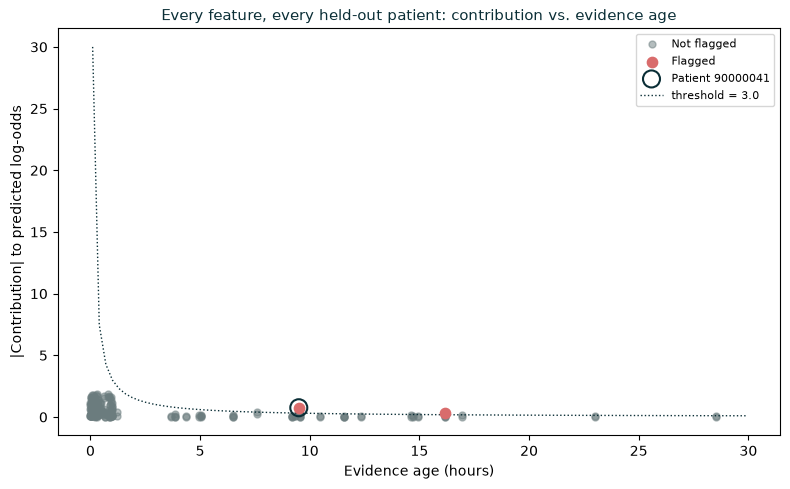

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pts[~pts.flagged].evidence_age_h, pts[~pts.flagged].abs_contribution,
           color="#6B7C7E", alpha=0.5, s=25, label="Not flagged")
ax.scatter(pts[pts.flagged].evidence_age_h, pts[pts.flagged].abs_contribution, color=CORAL, s=55, label="Flagged", zorder=3)
highlight = pts[(pts.subject_id == patient_id) & (pts.flagged)]
ax.scatter(highlight.evidence_age_h, highlight.abs_contribution, facecolors="none", edgecolors=DARK, s=150,
           linewidth=1.5, zorder=4, label=f"Patient {patient_id}")
h = np.linspace(0.1, pts.evidence_age_h.max() * 1.05, 100)
ax.plot(h, 3.0 / h, color=DARK, linestyle=":", linewidth=1, label="threshold = 3.0")
ax.set_xlabel("Evidence age (hours)")
ax.set_ylabel("|Contribution| to predicted log-odds")
ax.set_title("Every feature, every held-out patient: contribution vs. evidence age", fontsize=10.5, color=DARK)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Almost everything sits in the bottom-left corner, tightly clustered near zero evidence age, exactly where you'd want a model's confidence to come from. The threshold curve sweeps down and to the right, and only two points ever cross it. That sparsity is itself informative, showing that this is not a model riddled with old data/reasoning, but it is a model that mostly does the right thing, with one or two specific, checkable exceptions. This keeps the full pipeline honest and transparent, rather than "trusting it completely" or "distrust it entirely". AUCs might be perfect, but we need to move away from achieving highest possible accuracy, and more towards ensuring that any model or pipeline is trustworthy.

In a live deployment this is exactly the case a human reviewer should see flagged before the prediction ships, not because the model is wrong, it may well be right, but because *why* it\'s confident deserves a second look when the evidence backing that confidence is old enough that the world could have changed underneath it.

This is also a direct instance of the EU AI Act requirement coming up next. It requires a system that can explain not just its output but the evidentiary basis and freshness behind it is most of the way to meaningful human oversight, not just a post-hoc audit trail.

## Evaluation beyond AUROC

Every AUROC in this tutorial has been 1.000, and if you have been wondering whether that is suspicious, it should be. Let me show you exactly why it happens, because the reason matters more than the number.

In [ ]:
hr = aware_df["heartrate_last"]
solo_auroc = max(roc_auc_score(y, hr), 1 - roc_auc_score(y, hr))

print(f"AUROC of heartrate_last on its own, no model involved: {solo_auroc:.3f}")
print()
print(f"  Deteriorated  ({(y==1).sum()} patients): {hr[y==1].min():.0f} to {hr[y==1].max():.0f} bpm")
print(f"  Did not       ({(y==0).sum()} patients): {hr[y==0].min():.0f} to {hr[y==0].max():.0f} bpm")
print(f"  Gap between them: {hr[y==1].min() - hr[y==0].max():.1f} bpm, with no overlap at all")
print()
print(f'A single rule, "heart rate above {hr[y==0].max():.0f}", classifies all {len(y)} patients correctly.')

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.2))
bins = np.linspace(60, 135, 32)
ax.hist(hr[y == 0], bins=bins, color=TEAL, alpha=0.85, label="Did not deteriorate")
ax.hist(hr[y == 1], bins=bins, color=CORAL, alpha=0.85, label="Deteriorated")
ax.axvspan(hr[y == 0].max(), hr[y == 1].min(), color=AMBER, alpha=0.25)
ax.text((hr[y == 0].max() + hr[y == 1].min()) / 2, ax.get_ylim()[1] * 0.85,
        "no patient\nlands here", ha="center", fontsize=9, color=DARK)
ax.set_xlabel("heartrate_last at prediction time (bpm)")
ax.set_ylabel("Patients")
ax.set_title("Why every AUROC in this tutorial is 1.000", fontsize=11, color=DARK, fontweight="bold")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

This is a property of the generator, not of the models. `synthetic_generator.py` applies a deterioration shift of +38 bpm against a baseline standard deviation of 6, which is a shift of more than six standard deviations. Two groups separated that far cannot overlap. A real deteriorating patient might run fifteen to twenty-five bpm above their own baseline, against much larger variation between patients, and the distributions would sit on top of each other.

I am showing you this rather than quietly letting the 1.000 stand, for three reasons.

It is the honest reading of the number. The classification task in this corpus was solved before any model existed, so no AUROC in this tutorial should be read as evidence that a model is good.

It is why the tutorial's argument never rested on accuracy. Every real finding here came from somewhere else: the shortcut model's 0.562, the subgroup recall swing from a quarter to nearly ninety percent, the two flagged predictions in the audit, the Brier gap below. Those numbers move. If I had built the whole case on AUROC, this slide would have taken it apart.

And it is a fixable property, not a fact of life. Lower `DETERIORATION_SHIFT` in the generator, or raise `BASELINE_SD`, and the distributions start to overlap. Every downstream number changes with it, which is the exercise rather than the problem.

In [15]:
pipe_naive, Xte_naive, yte_naive, proba_naive = m.train_and_predict(naive_df, y)

print(f"Naive model  \u2014 AUROC: {roc_auc_score(yte_naive, proba_naive):.3f}  "
      f"Brier: {brier_score_loss(yte_naive, proba_naive):.4f}")
print(f"Aware model  \u2014 AUROC: {roc_auc_score(yte, proba):.3f}  "
      f"Brier: {brier_score_loss(yte, proba):.4f}")
print("\nAUROC ties or nearly ties. Brier score does not, the aware model is a little more honestly")
print("confident, not just equally accurate. At 75 synthetic patients that is a real but modest signal,")
print("worth taking more seriously at the scale of an actual hospital's data, where documentation-speed")
print("shortcuts have far more room to produce confidently wrong predictions than they do here.")

Naive model  — AUROC: 1.000  Brier: 0.0017
Aware model  — AUROC: 1.000  Brier: 0.0009

AUROC ties or nearly ties. Brier score does not, the aware model is a little more honestly
confident, not just equally accurate. At 75 synthetic patients that is a real but modest signal,
worth taking more seriously at the scale of an actual hospital's data, where documentation-speed
shortcuts have far more room to produce confidently wrong predictions than they do here.


Two claims were just made in text, "mostly near 0 or 1" and "a modest edge." Worth checking both against an actual picture rather than taking either on faith.

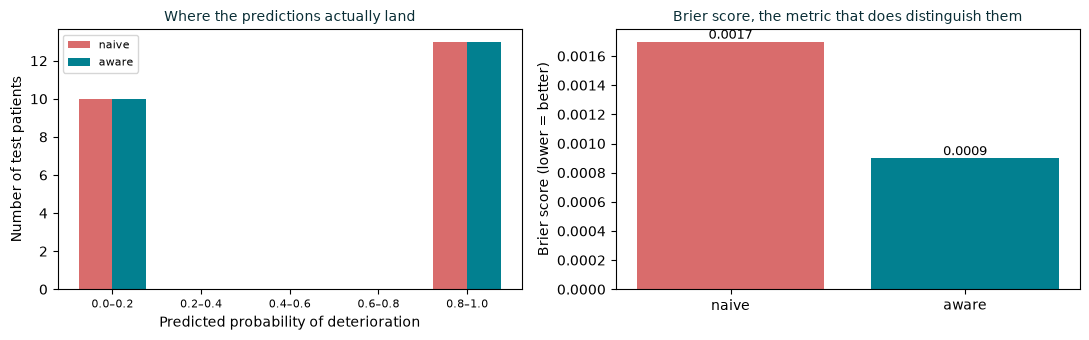

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

ax = axes[0]
bin_edges = np.linspace(0, 1, 6)
counts_naive, _ = np.histogram(proba_naive, bins=bin_edges)
counts_aware, _ = np.histogram(proba, bins=bin_edges)
x = np.arange(len(counts_naive))
width = 0.38
ax.bar(x - width/2, counts_naive, width, color=CORAL, label="naive")
ax.bar(x + width/2, counts_aware, width, color=TEAL, label="aware")
ax.set_xticks(x)
ax.set_xticklabels([f"{bin_edges[i]:.1f}\u2013{bin_edges[i+1]:.1f}" for i in range(len(counts_naive))], fontsize=8)
ax.set_xlabel("Predicted probability of deterioration")
ax.set_ylabel("Number of test patients")
ax.set_title("Where the predictions actually land", fontsize=10, color=DARK)
ax.legend(fontsize=8)

ax = axes[1]
briers = [brier_score_loss(yte_naive, proba_naive), brier_score_loss(yte, proba)]
ax.bar(["naive", "aware"], briers, color=[CORAL, TEAL])
ax.set_ylabel("Brier score (lower = better)")
ax.set_title("Brier score, the metric that does distinguish them", fontsize=10, color=DARK)
for i, b in enumerate(briers):
    ax.text(i, b, f"{b:.4f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.show()

Left panel is the honest version of "there's no calibration story here". Every single test patient, from both models, lands in the bottom or top bin, nothing in between. That's not a limitation of the chart, but it is what the underlying corpus actually looks like, cleanly separable, which is exactly why a calibration curve earlier would have shown you two flat, uninformative lines rather than a real finding.

Right panel is where the two models actually part ways. Same test patients, same rough placement, and the aware model is still measurably more honest about its own confidence. Small effect, real effect, worth taking seriously precisely because it shows up even in data this forgiving.

## Where this maps to regulation

The EU AI Act treats clinical prediction systems as high-risk, and its core requirements aren't abstract, they map directly onto specific artifacts you've already built across this tutorial, not onto anything new.

| AI Act requirement | What you already built |
|---|---|
| Traceability of training data and decisions | Block 1's schema-validated document object, with per-stream provenance tagging exactly where each fact came from |
| Record-keeping and audit trails | The amendment mechanism: a correction never overwrites history, it's appended, timestamped, and `document_schema.json` rejects one with no pointer back to what it corrects |
| Meaningful human oversight | This block's audit tool: a specific, checkable flag for when a model's confidence rests on evidence a human should look at again |
| Accuracy, robustness, and subgroup fairness | Block 2's subgroup recall breakdown, plus the Brier score comparison above, evaluation that doesn't stop at one aggregate number |
| Risk management across the system lifecycle | The whole naive-model-caught-cheating-then-fixed-architecturally arc of Block 2, done once, reusable as a pattern |

None of this makes a system compliant on its own, that's a legal determination, not a technical one. But "traceability" and "meaningful human oversight" stop being compliance checkboxes the moment you've built the specific mechanisms that make them concretely true, rather than asserted.

## The same code, a different domain

Here's the actual close. Every argument in this tutorial has been made using ICU data, on purpose, because high-stakes and concrete beats abstract. But the claim was never "hospitals are special." The claim was that temporal entanglement is a document engineering problem, one that shows up anywhere a document system captures an evolving real-world process under uncertainty. `generate_education_domain.py` builds a second, small, completely unrelated corpus: students in an online course, not patients in an ICU. Daily engagement instead of vital signs. Quiz scores, graded days later, instead of labs. Counselor notes, written well after a student actually started struggling, instead of clinical notes. An uncertain "started struggling" window instead of an uncertain deterioration onset.

Watch what doesn't change: `alignment.py`. Not a wrapper around it, not a re-skinned copy, the literal same import you've used since Block 2.

In [17]:
engagement = pd.read_csv(f"{DATA_DIR}/education_engagement.csv", parse_dates=["timestamp"])
assessments = pd.read_csv(f"{DATA_DIR}/education_assessments.csv", parse_dates=["assess_time", "result_time"])
edu_notes = pd.read_csv(f"{DATA_DIR}/education_notes.csv", parse_dates=["event_time", "storetime"])
edu_labels = pd.read_csv(f"{DATA_DIR}/education_labels.csv",
                          parse_dates=["true_onset_time", "possible_window_start", "possible_window_end"])

In [18]:
display(engagement.head(3))
display(assessments.head(3))
display(edu_notes.head(3))
display(edu_labels.head(3))

,student_id,timestamp,minutes_active
0,STU001,2026-02-02 18:00:00,59.1
1,STU001,2026-02-03 18:00:00,43.8
2,STU001,2026-02-04 19:00:00,52.4


,student_id,assess_time,result_time,score
0,STU001,2026-02-06 12:00:00,2026-02-07 17:08:00,91.7
1,STU001,2026-02-11 13:00:00,2026-02-14 02:09:00,83.0
2,STU001,2026-02-18 14:00:00,2026-02-21 20:14:00,75.8


,student_id,note_id,note_type,event_time,storetime,text
0,STU001,STU001-N1,routine_checkin,2026-02-12 00:00:00,2026-02-12 05:03:00,Routine check-in. Student engagement and perfo...
1,STU001,STU001-N2,concern_flagged,2026-03-17 00:00:00,2026-03-28 07:45:00,Noticed declining engagement and quiz performa...
2,STU001,STU001-N3,intervention,2026-03-30 05:16:00,2026-03-30 06:37:00,Met with student to discuss course difficultie...


,student_id,needs_intervention,true_onset_time,possible_window_start,possible_window_end
0,STU001,1,2026-03-17,2026-03-15,2026-03-22
1,STU002,1,2026-03-16,2026-03-14,2026-03-21
2,STU003,0,NaT,NaT,NaT


In [19]:
student_id = "STU001"
student_eng = engagement[engagement.student_id == student_id]
lrow = edu_labels.set_index("student_id").loc[student_id]
prediction_time = lrow.possible_window_start + pd.Timedelta(days=1)

/var/folders/wt/05f8y2kx0w79j50x0tz166tr0000gn/T/ipykernel_27063/4125716813.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  prediction_time = lrow.possible_window_start + pd.Timedelta(days=1)


In [21]:
# the exact same functions, completely unmodified, imported from alignment.py
window = al.naive_window(student_eng, "timestamp", prediction_time, lookback_hours=336)
last, slope, n = al.event_centered_trend(student_eng, "timestamp", "minutes_active", prediction_time, lookback_hours=336)
n_obs, completeness = al.missingness_features(student_eng, "timestamp", prediction_time, lookback_hours=336, expected_per_day=1)

print(f"al.naive_window()          -> {len(window)} engagement readings in a 14-day lookback")
print(f"al.event_centered_trend()  -> last={last:.1f} min/day, slope={slope:+.3f} min/day per hour, n={n}")
print(f"al.missingness_features()  -> {n_obs} logins observed, completeness ratio={completeness:.2f}")
print()
print("al.soft_event_label() across the onset window:")
for offset_days in [-3, -1, 0, 2, 4, 7]:
    t = lrow.possible_window_start + pd.Timedelta(days=offset_days)
    soft = al.soft_event_label(t, lrow.possible_window_start, lrow.possible_window_end)
    print(f"  day {offset_days:+d} relative to window start: soft label = {soft:.2f}")

al.naive_window()          -> 11 engagement readings in a 14-day lookback
al.event_centered_trend()  -> last=39.7 min/day, slope=-0.034 min/day per hour, n=11
al.missingness_features()  -> 11 logins observed, completeness ratio=0.79

al.soft_event_label() across the onset window:
  day -3 relative to window start: soft label = 0.00
  day -1 relative to window start: soft label = 0.00
  day +0 relative to window start: soft label = 0.00
  day +2 relative to window start: soft label = 0.29
  day +4 relative to window start: soft label = 0.57
  day +7 relative to window start: soft label = 1.00


/var/folders/wt/05f8y2kx0w79j50x0tz166tr0000gn/T/ipykernel_27063/3359443293.py:12: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  t = lrow.possible_window_start + pd.Timedelta(days=offset_days)


Zero modifications from the ICU temporal entanglement, applied one new domain. `naive_window` does not know or care whether it's windowing heart rate or login minutes. `soft_event_label` doesn't know whether the uncertain event is a deterioration or a student falling behind. That's not a coincidence, it's what "the framework generalizes" is supposed to mean when you actually check it rather than just claim it in an abstract.

Now the visual version, same grammar as every timeline plot in this tutorial: open circle for when something happened, filled marker for when it was recorded, the gap between them drawn to scale.

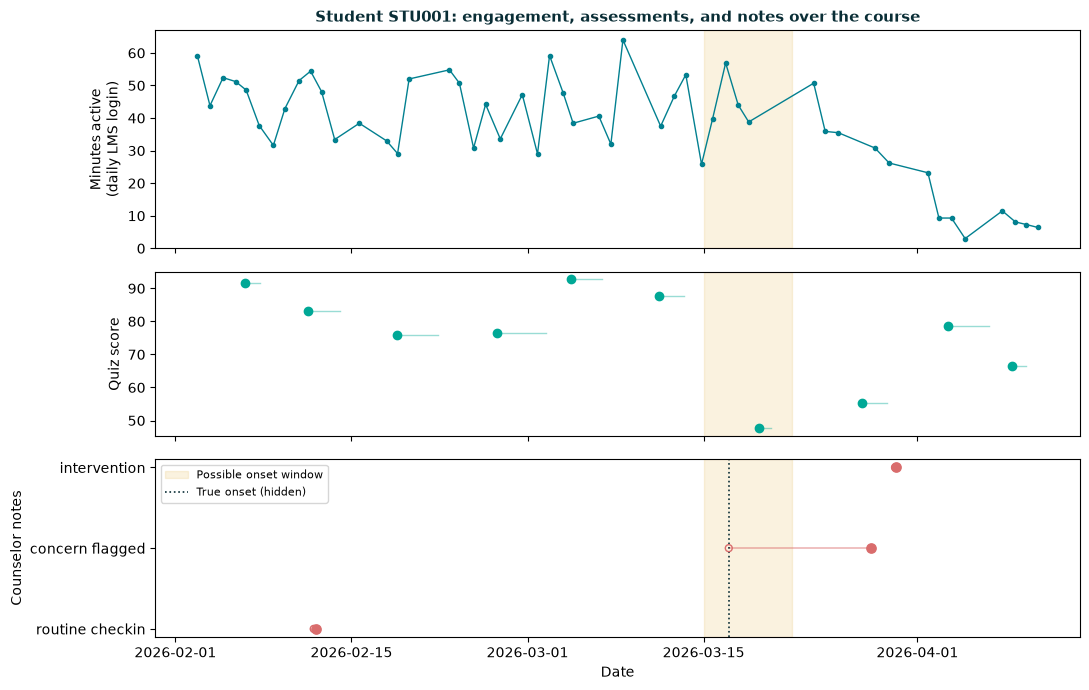


The 'concern flagged' note, the classroom's version of a clinical note, was charted 11.3 days after this student actually started struggling. Same problem, same shape, zero shared vocabulary with the word 'patient'.


In [22]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1.2, 1.3]))

sa = assessments[assessments.student_id == student_id]
sn = edu_notes[edu_notes.student_id == student_id]

ax = axes[0]
ax.plot(student_eng.timestamp, student_eng.minutes_active, "o-", color=TEAL, markersize=3, linewidth=1)
ax.axvspan(lrow.possible_window_start, lrow.possible_window_end, color=AMBER, alpha=0.15)
ax.set_ylabel("Minutes active\n(daily LMS login)")
ax.set_title(f"Student {student_id}: engagement, assessments, and notes over the course",
             fontsize=11, color=DARK, fontweight="bold")

ax = axes[1]
ax.plot(sa.assess_time, sa.score, "o", color=SEAFOAM, markersize=6)
for _, r in sa.iterrows():
    ax.plot([r.assess_time, r.result_time], [r.score, r.score], color=SEAFOAM, alpha=0.4, linewidth=1)
ax.axvspan(lrow.possible_window_start, lrow.possible_window_end, color=AMBER, alpha=0.15)
ax.set_ylabel("Quiz score")

ax = axes[2]
y_pos = {t: i for i, t in enumerate(sn.note_type.unique())}
for _, r in sn.iterrows():
    yv = y_pos[r.note_type]
    ax.plot([r.event_time, r.storetime], [yv, yv], color=CORAL, alpha=0.5, linewidth=1.2)
    ax.scatter(r.event_time, yv, color=CORAL, s=25, marker="o", facecolors="none", zorder=3)
    ax.scatter(r.storetime, yv, color=CORAL, s=45, marker="o", zorder=3)
ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels([t.replace("_", " ") for t in y_pos.keys()])
ax.axvspan(lrow.possible_window_start, lrow.possible_window_end, color=AMBER, alpha=0.15, label="Possible onset window")
ax.axvline(lrow.true_onset_time, color=DARK, linestyle=":", linewidth=1.2, label="True onset (hidden)")
ax.set_ylabel("Counselor notes")
ax.set_xlabel("Date")
ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()

lag_h = (sn[sn.note_type=="concern_flagged"].storetime.iloc[0] - lrow.true_onset_time).total_seconds() / 3600
print(f"\nThe 'concern flagged' note, the classroom's version of a clinical note, was charted "
      f"{lag_h/24:.1f} days after this student actually started struggling. Same problem, same shape, zero shared vocabulary with the word 'patient'.")

That's the argument this whole tutorial has been building toward, made visible instead of asserted: engagement drops right around the possible onset window, quiz scores follow within days, and the note that's supposed to catch it doesn't get written until well after the fact, the exact documentation-lag shape from Block 1's very first timeline plot, now playing out in a classroom `alignment.py` has never seen before this cell. Legal proceedings, financial audit trails, anywhere a document system captures an evolving process under timing uncertainty, this is the same problem wearing a different vocabulary.

## Your turn

- Lower `staleness_threshold` in `audit_temporal_consistency()` and see how many predictions get flagged. Raise it and watch them disappear. There is a real design decision hiding in that one number, and the answer should come from clinicians rather than from whatever I happened to type as a default.
- Change which modality a feature belongs to in the `MODALITY` dictionary. Move `vitals_completeness` out of the biosignal group and into its own "data quality" modality, then re-run the cross-modal chart. Grouping is an editorial choice, and it changes what the figure appears to say.
- Add a fifth modality. The echo reports carry `wall_motion_abnormality` and `valve_regurgitation`, both unused here. Does the picture change, and does the extra evidence arrive early enough to be worth having?
- Pick a patient with an amendment from Block 1 and re-run the multimodal section. The corrected drug now genuinely reaches the model through `text_has_diuretic`, which it never did before this block. Does the correction move the prediction?
- In the education corpus, change `student_id` to any of the eight struggling students. The decline timing differs by student on purpose, because real students do not fall behind on a schedule.
- The largest one, if you have the appetite. Financial audit trails appear in this tutorial's abstract and I never built them. What is the continuous signal there, and what is the delayed narrative? My claim is that `alignment.py` would not need to change. Test it.

## What you built

- Exact per-prediction attribution, the literal decomposition of what the model computed, checked against the model's own output rather than assumed
- A model that reads all four evidence streams in the record, biosignal, tabular, diagnostic studies, and the content of the notes, so that an explanation can cover the whole chart instead of the convenient half of it
- Cross-modal attribution fused with evidence age, the figure this tutorial has been pointing at since Block 0
- A reusable temporal-inconsistency audit tool, which found the same prediction I picked by eye and then proved across the held-out set that the pick was not luck
- An honest account of evaluation beyond AUROC, including the part where this corpus does not support the dramatic calibration story I would have preferred to tell
- A mapping from EU AI Act requirements to artefacts that already existed by the time we got there
- Proof, rather than a claim, that all four alignment functions run unchanged on a domain that has never heard of a patient

## Where the whole tutorial leaves you

Four blocks, one argument. Temporal entanglement is a document engineering problem first, and becomes a machine learning problem only once the representation has already gone wrong.

Block 0 introduced the corpus and the formats underneath it. Block 1 narrowed to a single chart, made you compute documentation lag by hand, and showed you a correction that changed what the record said halfway through a stay. Block 2 caught a model exploiting the gap none of that had closed yet, and then closed it. This block showed you how to see what the fixed model actually uses, across every stream rather than the easy ones, how to audit that automatically, how to explain it to a regulator, and that none of it was ever specific to an ICU.

Take `alignment.py`. Take the schema. Take the audit tool. They do not know what domain they are in, and you no longer have to treat the next one as a special case.